# Etapa 2 — Análise Exploratória (EDA)

Usamos o dataset já tratado na Etapa 1. Neste notebook fazemos as estatísticas descritivas, a matriz de correlação (Pearson e Spearman), os histogramas e os boxplots das variáveis numéricas.

In [22]:
import sys
import os
from pathlib import Path

try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir()),
    None
)

if _root is None:
    if not _in_colab:
        raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
    import subprocess
    subprocess.run(
        ['git', 'clone', 'https://github.com/Tassara7/cd2-trabalho.git', '/content/cd2-trabalho'],
        check=True
    )
    _root = Path('/content/cd2-trabalho')
    os.chdir(_root)

_root_str = str(_root.resolve())
if _root_str not in sys.path:
    sys.path.insert(0, _root_str)

## Imports

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import umap.umap_ as umap

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Carregamento dos dados

Lemos o CSV gerado na Etapa 1 (já limpo e com as variáveis numéricas padronizadas).

In [24]:
csv_path = _root / 'data' / 'processed' / 'restaurants_preprocessed.csv'
df = pd.read_csv(csv_path)

print(f"{df.shape[0]:,} restaurantes × {df.shape[1]} colunas")
df.head()

394,192 restaurantes × 8 colunas


,category,price_range,availableForScheduling,ibge,delivery_fee,delivery_time,minimumOrderValue,rating
0,Marmita,CHEAPEST,0,5300108,-0.659290,-1.251447,-0.562502,-1.094339
1,Açaí,CHEAPEST,0,5300108,0.292185,0.921866,-0.562502,-1.094339
2,Bebidas,MODERATE,0,5300108,1.243660,1.497155,-1.230091,-1.094339
3,Carnes,CHEAPEST,0,5300108,2.314070,1.049708,0.772676,-1.094339
4,Brasileira,CHEAPEST,0,5300108,1.243660,0.730104,0.772676,-1.094339


In [25]:
col_num = ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating']
col_cat = ['category', 'price_range', 'availableForScheduling', 'ibge']

## 1. Estatísticas descritivas

As variáveis numéricas já vêm padronizadas da Etapa 1 (StandardScaler), então a média fica próxima de 0 e o desvio próximo de 1. O `describe()` mostra a dispersão relativa de cada uma.

In [26]:
df[col_num].describe()

,delivery_fee,delivery_time,minimumOrderValue,rating
count,3.941920e+05,3.941920e+05,3.941920e+05,3.941920e+05
mean,3.691581e-17,7.383161e-17,1.845790e-17,8.075332e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-1.608387e+00,-2.849472e+00,-1.897679e+00,-1.094339e+00
25%,-6.569116e-01,-7.400791e-01,-5.625019e-01,-1.094339e+00
50%,-1.811740e-01,-1.008693e-01,1.050868e-01,6.136197e-01
75%,6.489881e-01,8.579455e-01,7.726755e-01,9.668191e-01
max,2.554317e+00,3.223022e+00,2.775442e+00,1.090260e+00


In [27]:
print("Top 10 categorias:")
print(df['category'].value_counts().head(10))
print()
print("Faixa de preço:")
print(df['price_range'].value_counts())
print()
print(f"Com agendamento disponível: {df['availableForScheduling'].mean() * 100:.1f}%")
print(f"Municípios distintos (ibge): {df['ibge'].nunique():,}")

Top 10 categorias:
category
Lanches          97395
Brasileira       72032
Doces & Bolos    38916
Pizza            34666
Açaí             21924
Marmita          16389
Bebidas          12616
Japonesa         12539
Saudável          9562
Salgados          9478
Name: count, dtype: int64

Faixa de preço:
price_range
CHEAPEST          287603
MODERATE           42996
CHEAP              42235
EXPENSIVE          14294
MOST_EXPENSIVE      7064
Name: count, dtype: int64

Com agendamento disponível: 0.4%
Municípios distintos (ibge): 1,448


## 2. Matriz de correlação (Pearson e Spearman)

Pearson mede relação linear; Spearman mede relação por postos (monotônica). Comparar os dois ajuda a ver se a relação é linear ou só crescente/decrescente.

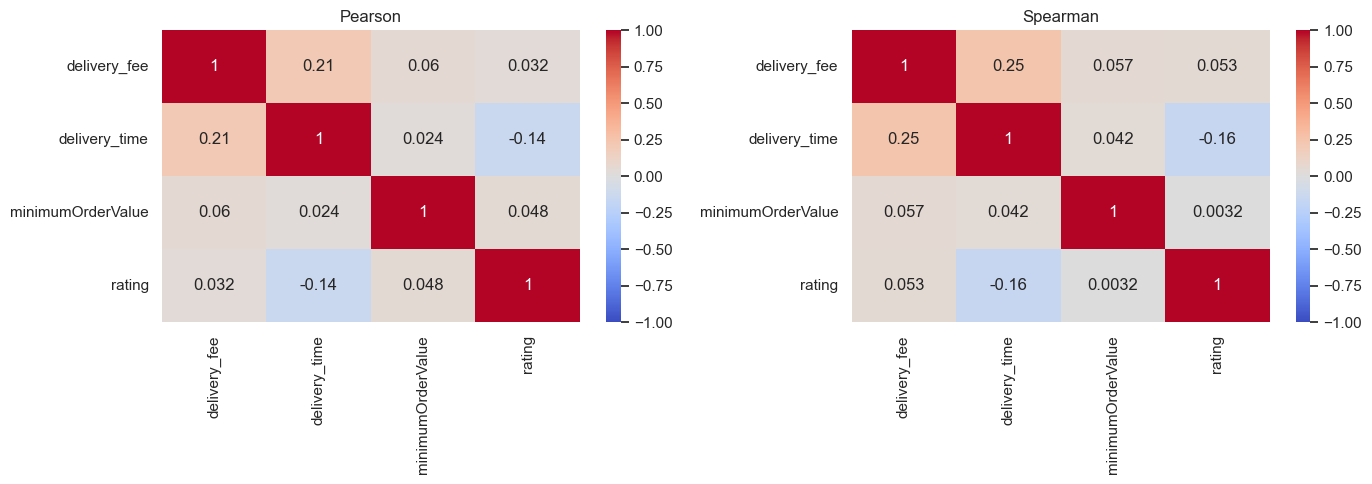

In [28]:
corr_p = df[col_num].corr(method='pearson')
corr_s = df[col_num].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_p, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson')
sns.heatmap(corr_s, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman')
plt.tight_layout()
plt.show()

## 3. Histogramas

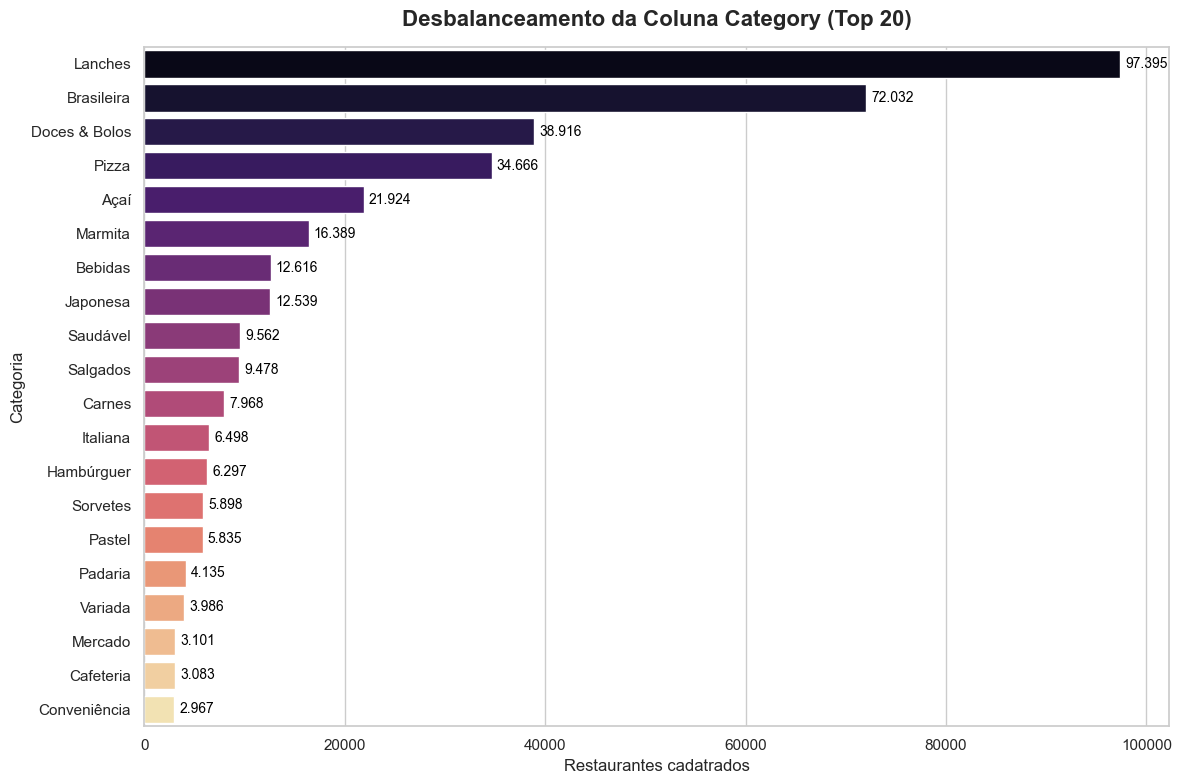

In [29]:
# Plotando a distribuição de categorias:
top_20_categorias = df['category'].value_counts().nlargest(20)
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    x=top_20_categorias.values,
    y=top_20_categorias.index,
    hue=top_20_categorias.index,
    palette="magma",
    legend=False
)

plt.title('Desbalanceamento da Coluna Category (Top 20)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Restaurantes cadatrados', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

for i, v in enumerate(top_20_categorias.values):
    ax.text(v + 500, i, f"{v:,}".replace(',', '.'), color='black', va='center', fontsize=10)

plt.tight_layout()

plt.show()

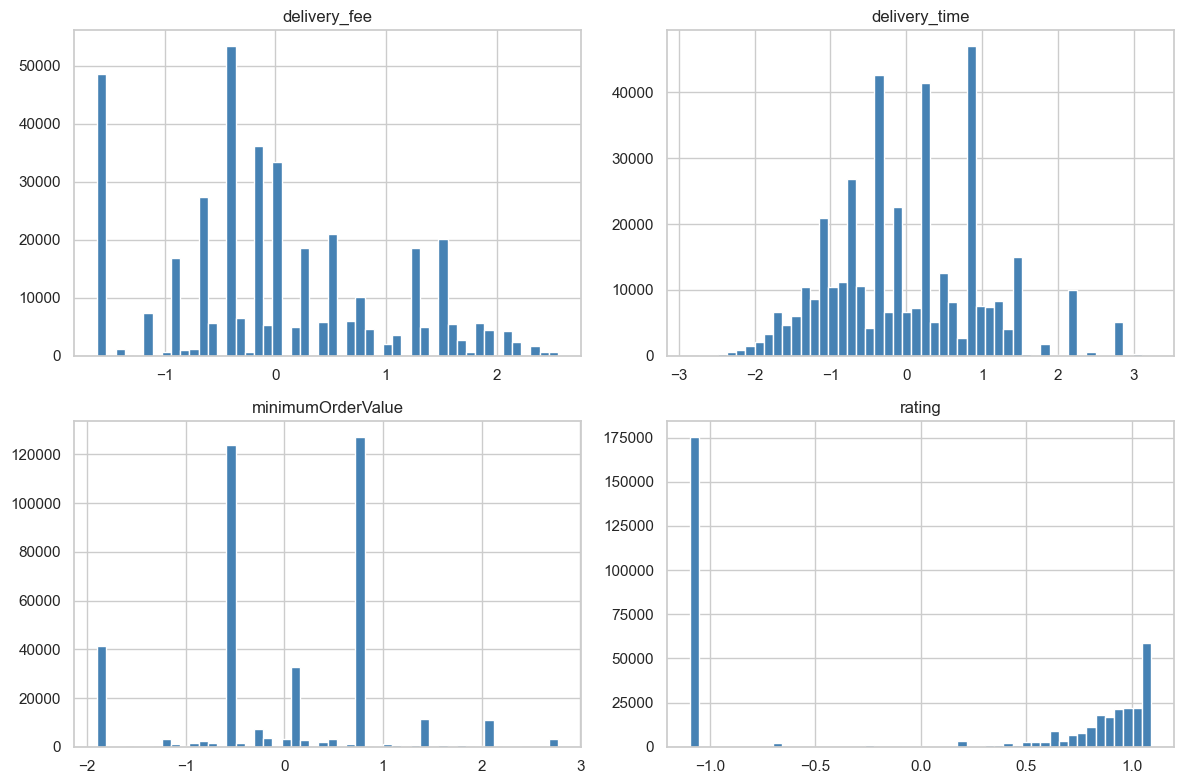

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), col_num):
    ax.hist(df[col], bins=50, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Boxplots

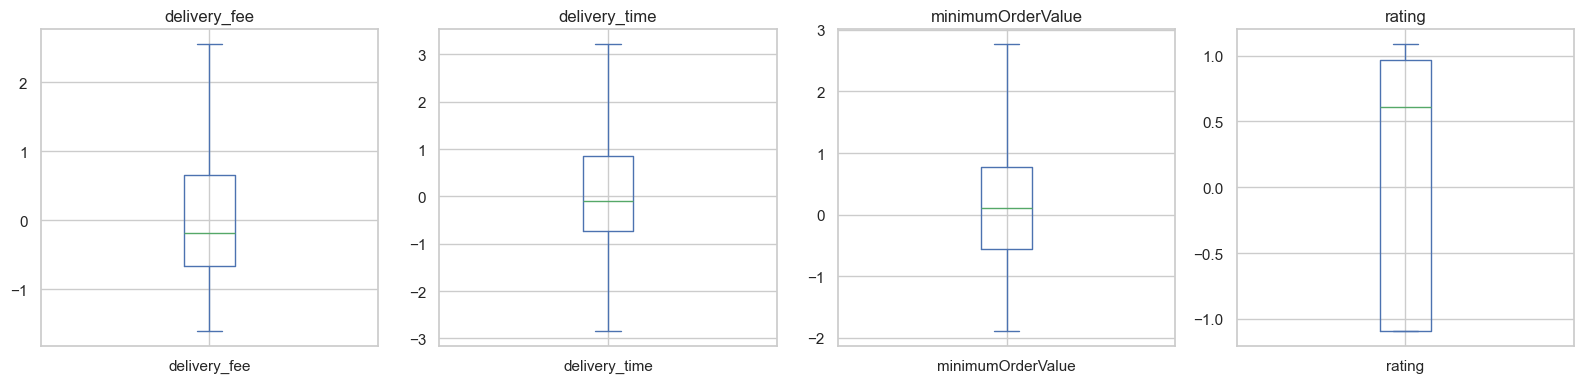

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, col_num):
    df[col].plot.box(ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

As correlações entre as variáveis numéricas são fracas (todas abaixo de 0,3). A mais forte é entre `delivery_fee` e `delivery_time` (positiva, ~0,2), e `delivery_time` tem uma leve correlação negativa com `rating`. Como Pearson e Spearman ficam próximos, as relações são praticamente lineares. No geral há pouca redundância entre as variáveis. Os histogramas e boxplots mostram as distribuições já padronizadas, com alguns valores extremos mesmo após a limpeza da Etapa 1. Nos próximos pontos da Etapa 2 vamos tratar a redução de redundância e a análise de componentes (PCA).

## 5. Tentativa de PCA e resultados obtidos

In [32]:
from sklearn.decomposition import PCA
import numpy as np

X = df[col_num].values
pca = PCA()
pca.fit(X)

evr = pca.explained_variance_ratio_
acum = np.cumsum(evr)

tab_var = pd.DataFrame(
    {'variancia_explicada': evr, 'acumulada': acum},
    index=[f'PC{i}' for i in range(1, len(evr) + 1)]
)
tab_var.round(3)

,variancia_explicada,acumulada
PC1,0.311,0.311
PC2,0.271,0.582
PC3,0.235,0.817
PC4,0.183,1.000


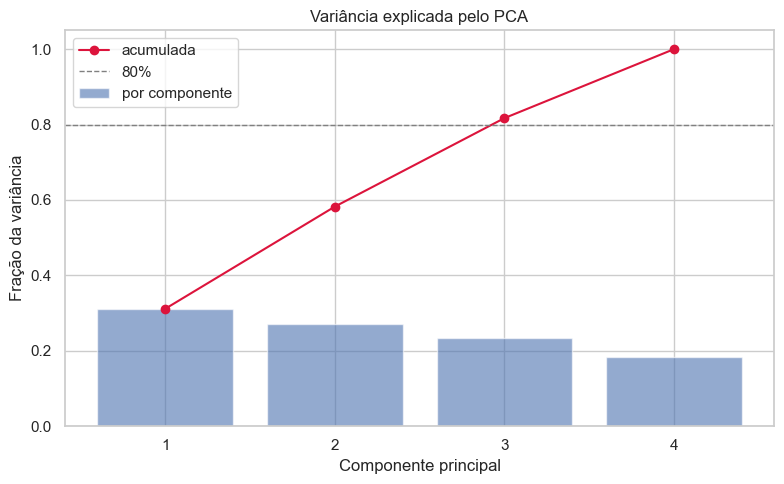

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
pcs = range(1, len(evr) + 1)
ax.bar(pcs, evr, alpha=0.6, label='por componente')
ax.plot(pcs, acum, 'o-', color='crimson', label='acumulada')
ax.axhline(0.8, ls='--', color='gray', lw=1, label='80%')
ax.set_xticks(list(pcs))
ax.set_xlabel('Componente principal')
ax.set_ylabel('Fração da variância')
ax.set_title('Variância explicada pelo PCA')
ax.legend()
plt.tight_layout()
plt.show()

O gráfico mostra que a variância está bastante distribuída entre as quatro componentes (31%, 27%, 24% e 18%), sem nenhuma se destacar. Juntas, PC1 e PC2 explicam cerca de 58% da informação, e só a partir da PC3 chegamos aos 80%. Isso indica que o PCA praticamente não comprime estes dados. Já esperavamos esse resultado, dado que as variáveis apresentaram correlações fracas na análise anterior. Como não há redundância para o PCA explorar, cada componente carrega informação própria.

### Do que é feito cada componente?

In [34]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=col_num,
    columns=[f'PC{i}' for i in range(1, len(evr) + 1)]
)
loadings.round(3)

,PC1,PC2,PC3,PC4
delivery_fee,0.622,0.329,-0.391,-0.594
delivery_time,0.712,-0.147,-0.033,0.686
minimumOrderValue,0.167,0.602,0.781,-0.006
rating,-0.281,0.713,-0.486,0.421


Podemos ver que nenhum componente é dominado exclusivamente por uma única variável.

### Plotagem dos resultados do PCA

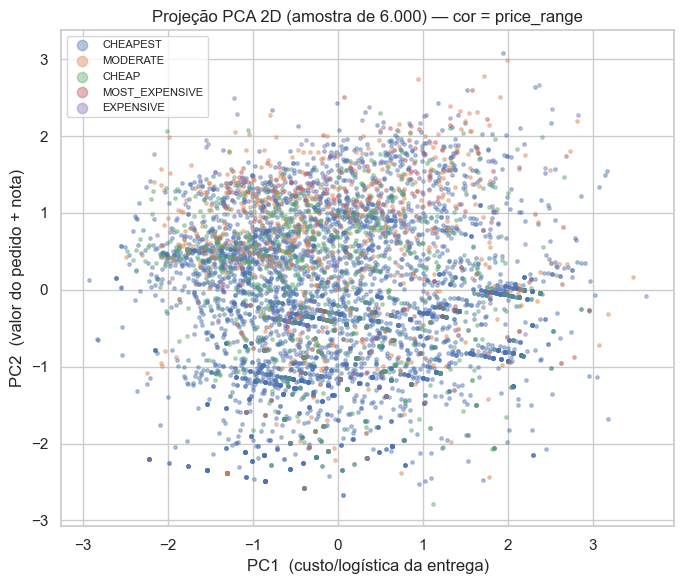

In [35]:
proj = pca.transform(X)[:, :2]

rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=6000, replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
for faixa in df['price_range'].unique():
    m = df['price_range'].values[idx] == faixa
    ax.scatter(proj[idx][m, 0], proj[idx][m, 1], s=6, alpha=0.4, label=faixa)
ax.set_xlabel('PC1  (custo/logística da entrega)')
ax.set_ylabel('PC2  (valor do pedido + nota)')
ax.set_title('Projeção PCA 2D (amostra de 6.000) — cor = price_range')
ax.legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

Cada ponto representa um restaurante, posicionado pelas suas coordenadas em PC1 e PC2, com a cor indicando a faixa de preço. Os pontos formam uma nuvem única, sem grupos bem definidos, e as faixas de preço aparecem misturadas pelo gráfico. Isso é coerente com a baixa correlação entre as variáveis e com a variância distribuída entre as componentes: o PCA não encontra uma separação clara nos dados. Vale lembrar que essa projeção usa apenas PC1 e PC2, ou seja, cerca de 58% da informação total.

## 6. Feature Selection Final

Como as variáveis não apresentaram uma alta correlação, não há uma redundância clara a ser eliminada (gerou baixa variância explicada), não justifica o uso do PCA. Faremos uma feature selection manual e usaremos o UMAP.

In [36]:
df_features = df.copy()
top_10_categorias = df['category'].value_counts().nlargest(10).index

# Primeiramente será removida a coluna 'availableForScheduling' pois é pouco relevante e com baixa representatividade no dataset (0,4% apenas).
df_features.drop(columns=['availableForScheduling'], inplace=True)
col_cat.remove('availableForScheduling')

# Agruparemos a coluna 'category' em categorias mais amplas para reduzir a cardinalidade e desbalanceamento. Se a categoria original estiver no top 10, mantém. Se não, vira 'Outros'
# Não faremos tratativas extras nessa coluna, ela será utilizada apenas para a analise final dos resultados, não será utilizada no treinamento do modelo.
df_features['category_grouped'] = df_features['category'].where(df_features['category'].isin(top_10_categorias), 'Outros')

# Vamos enumerar 'price_range' (Mapeamento Ordinal)
mapa_precos = {
    'CHEAPEST': 1,
    'CHEAP': 2,
    'MODERATE': 3,
    'EXPENSIVE': 4,
    'MOST_EXPENSIVE': 5
}
# O map substitui as strings pelos números correspondentes
df_features['price_encoded'] = df_features['price_range'].map(mapa_precos)

col_cat.remove('price_range')
col_cat.remove('category')

col_num.append('price_encoded')
col_cat.append('category_grouped')

df_features.drop(columns=['price_range', 'category'], inplace=True)

df_features.head(5)


,ibge,delivery_fee,delivery_time,minimumOrderValue,rating,category_grouped,price_encoded
0,5300108,-0.659290,-1.251447,-0.562502,-1.094339,Marmita,1
1,5300108,0.292185,0.921866,-0.562502,-1.094339,Açaí,1
2,5300108,1.243660,1.497155,-1.230091,-1.094339,Bebidas,3
3,5300108,2.314070,1.049708,0.772676,-1.094339,Outros,1
4,5300108,1.243660,0.730104,0.772676,-1.094339,Brasileira,1


## 7. UMAP

Separação em dataset original e processado

In [37]:
# Dataframe original
df_priori = df.copy()
col_num_priori = ['delivery_fee', 'delivery_time', 'minimumOrderValue', 'rating', 'availableForScheduling']

df_priori = df_priori.dropna(subset=col_num_priori + ['price_range'])
dados_originais = df_priori[col_num_priori].values

df_amostra_priori, _, amostra_numerica_priori, _ = train_test_split(
    df_priori,
    dados_originais,
    train_size=5000,
    random_state=42
)

redutor_priori = umap.UMAP(n_components=2, metric='euclidean', random_state=42, n_neighbors=15, min_dist=0.1)
embedding_priori = redutor_priori.fit_transform(amostra_numerica_priori)

df_amostra_priori['umap_x'] = embedding_priori[:, 0]
df_amostra_priori['umap_y'] = embedding_priori[:, 1]

# Dataframe gerado
df_umap = df_features.dropna(subset=col_num).copy()

scaler = StandardScaler()
dados_escalados = scaler.fit_transform(df_umap[col_num])

df_amostra, _, amostra_escalada, _ = train_test_split(
df_umap,
dados_escalados,
train_size=5000,
random_state=42
)

redutor = umap.UMAP(n_components=2, metric='euclidean', random_state=42, n_neighbors=15, min_dist=0.1)

embedding_umap = redutor.fit_transform(amostra_escalada)

df_amostra['umap_x'] = embedding_umap[:, 0]
df_amostra['umap_y'] = embedding_umap[:, 1]

C:\Users\joaog\Pessoal\cd2-trabalho\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\joaog\Pessoal\cd2-trabalho\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\joaog\Pessoal\cd2-trabalho\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotagem dos resultados

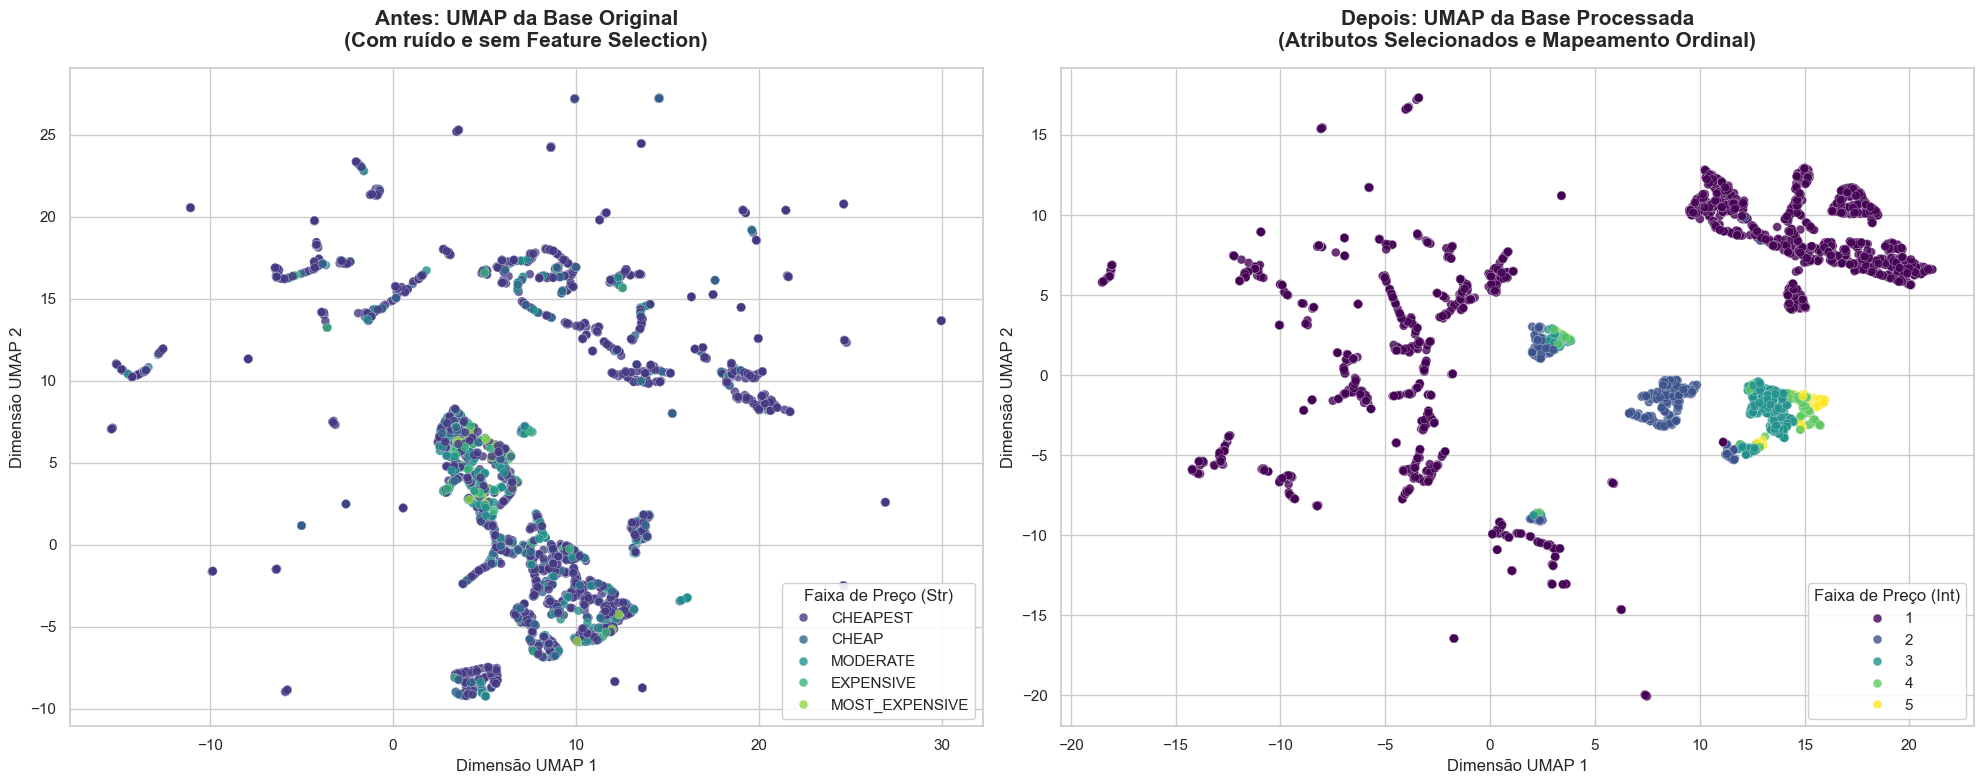

In [41]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

#plotagem dos dados originais
ordem_precos_str = ['CHEAPEST', 'CHEAP', 'MODERATE', 'EXPENSIVE', 'MOST_EXPENSIVE']

sns.scatterplot(
    ax=axes[0],
    data=df_amostra_priori,
    x='umap_x',
    y='umap_y',
    hue='price_range',
    hue_order=ordem_precos_str,
    palette='viridis',
    s=40, alpha=0.8, edgecolor='w', linewidth=0.2
)

axes[0].set_title('Antes: UMAP da Base Original\n(Com ruído e sem Feature Selection)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Dimensão UMAP 1', fontsize=12)
axes[0].set_ylabel('Dimensão UMAP 2', fontsize=12)

axes[0].legend(title='Faixa de Preço (Str)', loc='lower right', framealpha=0.9)

# Plotagem dos dados processados
sns.scatterplot(
    ax=axes[1],
    data=df_amostra,
    x='umap_x',
    y='umap_y',
    hue='price_encoded',
    palette='viridis',
    s=40, alpha=0.8, edgecolor='w', linewidth=0.2
)

axes[1].set_title('Depois: UMAP da Base Processada\n(Atributos Selecionados e Mapeamento Ordinal)', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Dimensão UMAP 1', fontsize=12)
axes[1].set_ylabel('Dimensão UMAP 2', fontsize=12)
axes[1].legend(title='Faixa de Preço (Int)', loc='lower right', framealpha=0.9)

plt.tight_layout()

plt.show()

In [40]:
df_numerico_escalado = pd.DataFrame(
    dados_escalados,
    columns=col_num,
    index=df_umap.index
)
df_categorico = df_umap[col_cat]

df_final = pd.concat([df_numerico_escalado, df_categorico], axis=1)
df_final.head(5)

output_path = _root / 'data' / 'processed' / 'restaurants_final.csv'
df_final.to_csv(output_path, index=False)
